In [2]:
import sys
print(sys.executable)

d:\RAG\Demo Proj\.venv\Scripts\python.exe


In [11]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [13]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper


### Arxiv 
- Its a popular open source project where all research papers published

### Wikipedia
- We all know

In [14]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=3, max_summary_length=200)
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=3, max_summary_length=200)
result_arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
result_wikipedia=WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
result_arxiv.invoke("What are the latest research papers on deep learning?")

'Published: 2023-01-03\nTitle: Deep Learning and Computational Physics (Lecture Notes)\nAuthors: Deep Ray, Orazio Pinti, Assad A. Oberai\nSummary: These notes were compiled as lecture notes for a course developed and taught at the University of the Southern California. They should be accessible to a typical engineering graduate student with a strong background in Applied Mathematics.\n  The main objective of these notes is to introduce a student who is familiar with concepts in linear algebra and partial differential equations to select topics in deep learning. These lecture notes exploit the strong connections between deep learning algorithms and the more conventional techniques of computational physics to achieve two goals. First, they use concepts from computational physics to develop an understanding of deep learning algorithms. Not surprisingly, many concepts in deep learning can be connected to similar concepts in computational physics, and one can utilize this connection to bett

In [15]:
result_wikipedia.invoke("What is Machine Learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation (mathematical programming) methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\nFrom a theoretical viewpoint, probably approximately correct learning provides a mathematical and statistical framework for describing machine learning. Most traditional machine learning and deep learning algorithms can be described as empiric

In [7]:

from langchain_openai import ChatOpenAI
llm=ChatOpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
    model="nvidia/nemotron-3-nano-30b-a3b:free"
)

In [16]:
tools = [result_arxiv, result_wikipedia]
tool_all=llm.bind_tools(tools)
response=tool_all.invoke("What are the latest research papers on deep learning and what is Machine Learning?")
print(response)
print(response.tool_calls)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 463, 'prompt_tokens': 442, 'total_tokens': 905, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 504, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-nano-30b-a3b:free', 'system_fingerprint': None, 'id': 'gen-1775545027-CMFlhQPoPMcJhMTE3OYq', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d66bb-1b65-73a3-b67a-d5aef0bb921b-0' tool_calls=[{'name': 'arxiv', 'args': {'query': 'deep learning'}, 'id': 'call_20e1bc7a005647eaa69ee690', 'type': 'tool_call'}, {'name': 'wikipedia', 'args': {'qu

In [21]:
from langchain_tavily import TavilySearch
tool_travily=TavilySearch(
    max_results=3,
    topic="general"
)
result=tool_travily.invoke("What are the latest news on AI?")
print(result["results"])

[{'url': 'https://www.nbcnews.com/artificial-intelligence', 'title': 'Artificial intelligence - NBC News', 'content': "The latest news and top stories on artificial intelligence, including AI chatbots like Microsoft's ChatGPT, Apple's AI Chatbot and Google's Bard.", 'score': 0.7931224, 'raw_content': None}, {'url': 'https://www.reuters.com/technology/artificial-intelligence/', 'title': 'AI News | Latest Headlines and Developments | Reuters', 'content': 'Explore the latest artificial intelligence news with Reuters - from AI breakthroughs and technology trends to regulation, ethics, business and global', 'score': 0.758958, 'raw_content': None}, {'url': 'https://www.artificialintelligence-news.com/', 'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth', 'content': 'Secure governance accelerates financial AI revenue growth · Thailand becomes one of the first in Asia to get the Sora app · Malaysia launches Ryt Bank, its', 'score': 0.7451949, 'raw_content': None}]


In [22]:
def add(a: int, b: int) -> int:
    """
    Adds two integers and returns the result.
    This tool will take two integers as input and return their sum. It can be used for simple arithmetic operations.
    Example usage:  
    result = add(5, 3)
    print(result)  # Output: 8
    
    """
    return a + b

def subtract(a: int, b: int) -> int:
    """
    Subtracts the second integer from the first and returns the result.
    This tool will take two integers as input and return the difference. It can be used for simple arithmetic operations.
    Example usage:  
    result = subtract(5, 3)
    print(result)  # Output: 2
    
    """
    return a - b

In [23]:
tools=[add, subtract, result_arxiv, result_wikipedia, tool_travily]
tool_all=llm.bind_tools(tools)

In [35]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage,HumanMessage,AIMessage,ToolMessage
from typing import Annotated
from typing_extensions import TypedDict
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]


In [ ]:
#tool calling LLM node
def tool_call(state:State):
    return {"messages":tool_all.invoke(state["messages"])}


In [29]:
from langgraph.prebuilt import ToolNode,tools_condition
tool_node=ToolNode(tools)

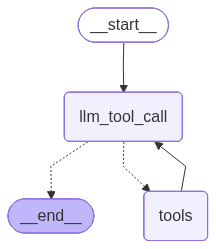

In [ ]:
from langgraph.graph import StateGraph,START,END
from IPython.display import display,Image
builder=StateGraph(State)
builder.add_node("llm_tool_call",tool_call)
#the name of the tool node must be "tools" for the tools_condition to work
builder.add_node("tools",tool_node)
builder.add_edge(START,"llm_tool_call")
builder.add_conditional_edges(
    "llm_tool_call",
    #if latest message is tool call, then go to tool node, else go to end
    tools_condition,
    
)
builder.add_edge("tools","llm_tool_call")
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
messages=graph.invoke({"messages": [HumanMessage(content="What are the latest research papers on deep learning and what is Machine Learning?")]})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What are the latest research papers on deep learning and what is Machine Learning?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_4ca955904b724f188ff7c2df)
 Call ID: call_4ca955904b724f188ff7c2df
  Args:
    exclude_domains: ['microsoft.com', 'google.com', 'nvidia.com']
    search_depth: advanced
    topic: general
    query: latest research papers on deep learning
    time_range: year
    include_domains: ['arxiv.org']
  wikipedia (call_22e4a1cea0b34cac9e121b76)
 Call ID: call_22e4a1cea0b34cac9e121b76
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: tavily_search

{"query": "latest research papers on deep learning", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://arxiv.org/html/2602.15926v1", "title": "A Study on Real-time Ob